# 00 · What is a diffusion model?

Welcome to **nanoDiffusion** — we learn diffusion models by building one, step by
step, in the spirit of nanoGPT.

The whole idea in one sentence:

> **Gradually destroy structure in data by adding noise, then train a neural
> network to reverse that destruction — and you get a generator.**

If a network can look at a slightly-noisy image and remove a little noise, then we
can start from *pure noise* and repeatedly denoise until a brand-new, realistic
sample emerges. That's it. Everything else is making this precise and efficient.

We start in **2D**, because we can plot the *entire* data distribution and
literally watch it dissolve and reappear.

In [1]:
import torch
import matplotlib.pyplot as plt

from nanodiffusion.utils import pick_device, set_seed, scatter_2d
from nanodiffusion.data import toy2d
from nanodiffusion.schedules import NoiseSchedule
from nanodiffusion.forward import add_noise

set_seed(0)
device = pick_device()
print("Running on:", device)

Matplotlib is building the font cache; this may take a moment.


Running on: mps


## Our data: a 2D "swiss roll"

Our "dataset" is a cloud of points arranged in a spiral. This stands in for the
true data distribution $q(x_0)$ that we want to learn to sample from.

data shape: (8000, 2)


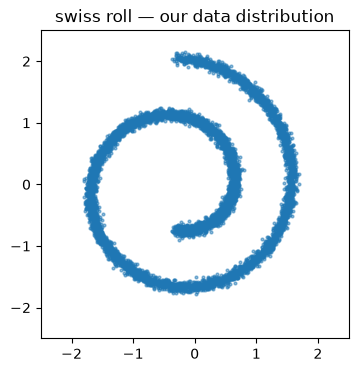

In [2]:
data = toy2d("swiss_roll", n=8000)
print("data shape:", tuple(data.shape))

fig, ax = plt.subplots(figsize=(4, 4))
scatter_2d(ax, data, "swiss roll — our data distribution")
plt.show()

## The forward process: destroy the data

We corrupt the data in small steps. After enough steps, *any* dataset turns into a
featureless blob of Gaussian noise — the spiral is gone. Watch it happen: from
$t=0$ (clean) to $t=T$ (pure noise).

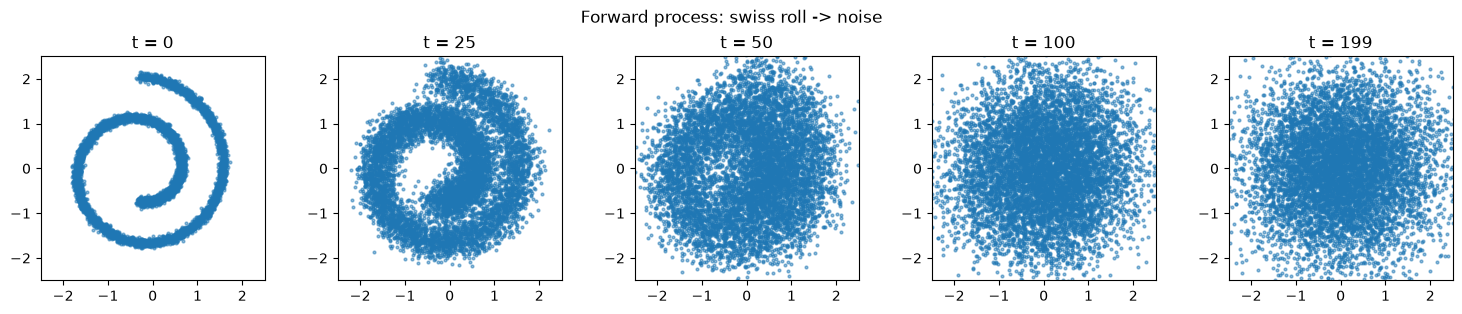

In [3]:
schedule = NoiseSchedule.make("cosine", timesteps=200)

ts = [0, 25, 50, 100, 199]
fig, axes = plt.subplots(1, len(ts), figsize=(3 * len(ts), 3))
for ax, t in zip(axes, ts):
    t_batch = torch.full((data.shape[0],), t, dtype=torch.long)
    x_t, _ = add_noise(data, t_batch, schedule)
    scatter_2d(ax, x_t, f"t = {t}")
plt.suptitle("Forward process: swiss roll -> noise")
plt.tight_layout()
plt.show()

## The reverse process: our goal

Training gives us a network that can undo *one* small noising step. To generate,
we start from the noise on the right and walk **backwards**, step by step, until a
fresh swiss roll appears on the left. We'll build exactly that over the next
notebooks.

## Roadmap

| Notebook | What we build |
|----------|---------------|
| **00 (here)** | Intuition |
| **01** | The forward process, noise schedules, the "nice property" |
| **02** | What the network predicts (ε), and the simple loss |
| **03** | The sampler: noise → data |

Then Part 2 scales this exact machinery up to real images with a U-Net.
Onwards to notebook 01.